In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

import sys
import os
import pickle
from tqdm import tqdm
# Get the absolute path to the folder containing `utils`
utils_path = os.path.abspath('../')
if utils_path not in sys.path:
    sys.path.append(utils_path)

os.environ["CUDA_VISIBLE_DEVICES"] = "1" # second gpu
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"

# from utils import *

# az.style.use("arviz-docgrid")
plt.rcParams['figure.dpi'] = 140

experiment_orientations = [159, 123, 87, 51, 15]
subjects = ["01", "02", "03", "04", "05", "06", "07" ,"09", "10", "11", "12"]
median_key = {15:0, 51:1, 87:2, 123:3, 159:4}
std_key = {15:0, 51:1, 87:2, 123:3, 159:4}

c_table = pd.read_csv('../data_caches/ctiraltable.csv')
med = np.load('../data_caches/med.npy')
std = np.load('../data_caches/std.npy')
ctimetable = np.load('../data_caches/ctimetable.npy')
r_table = pd.read_csv('../data_caches/rtrialtable.csv', index_col=0)
(x, y, d, r, e, cd, ce) = np.load('../data_caches/rtimetable.npy', allow_pickle=True)

## Real

In [2]:
def impute_with_median(data):
    median_rt = np.nanmedian(data)
    rt_imputed = data.copy()
    rt_imputed[rt_imputed == 0] = median_rt
    return rt_imputed

def impute_with_lin_interpolation(data):
    oshape = data.shape
    rt_imputed = data.flatten().copy()
    idx = np.arange(rt_imputed.size)
    good = rt_imputed != 0
    
    # interpolate where values are zero
    rt_imputed[rt_imputed == 0] = np.interp(
        idx[~good], 
        idx[good], 
        rt_imputed[good], 
    )
    return rt_imputed.reshape(oshape)

### Calculating RT and evidence for 5 different choices

In [3]:
r_table[["subj", "target", "t_calib", "resp"]].head()

,subj,target,t_calib,resp
0,1,159.0,145.788047,148.685925
1,1,123.0,136.060195,129.253756
2,1,51.0,33.954344,124.965094
3,1,159.0,145.788047,145.702460
4,1,15.0,18.896223,144.334808


   subj      att   coh      exp_al        rt  choice
0     1  divided  high    expected  1.025000       4
1     1  focused  high  unexpected  0.250000       3
2     1  divided  high    expected  0.725000       4
3     1  divided   low  unexpected  0.166667       4
4     1  divided   low    expected  0.658333       4


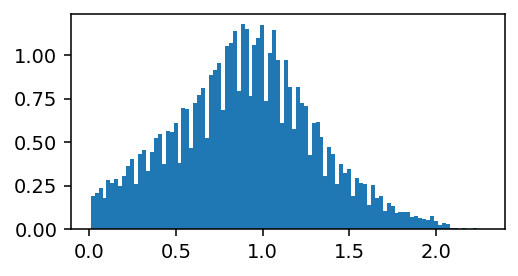

In [4]:
data = r_table[['subj', "att", "coh", "exp_al", "target", "resp"]].copy()

raw_rt = (r_table['f_resp'].values - 250) * (1/120)
# aug_rt = impute_with_lin_interpolation(raw_rt)

col_to_angle = {0: 15, 1: 51, 2: 87, 3: 123, 4: 159}
def map_response(subj, resp):
    # select row for subject (1-indexed)
    row = med[subj - 1]
    # find index of closest representative angle
    idx = np.abs(row - resp).argmin()
    return col_to_angle[idx]
data['afc_resp'] = data.apply(lambda r: map_response(r['subj'], r['resp']), axis=1)

resp = data['afc_resp'].map(median_key)

data['rt'] = raw_rt
data['choice'] = resp

# drop where rt == 0
data = data[data['rt'] != 0].reset_index(drop=True)

print(data[['subj', "att", "coh", "exp_al", "rt", "choice"]].head())

plt.figure(figsize=(4, 2))
# plt.hist(data.rt.sample(n=200, replace=False, random_state=42).values.flatten(), bins=100, density=True)
plt.hist(data.rt.values.flatten(), bins=100, density=True)
plt.show()

In [5]:
# Condition masks
masks = [
    data.att == "focused",
    data.att == "divided",
    data.coh == "high",
    data.coh == "low",
    data.exp_al == "expected",
    data.exp_al == "unexpected"
]

rts = []
resps = []
for mask in masks:
    rt = []
    rs = []
    for sid in data.subj.unique():
        sub_data = data[mask & (data.subj == sid)]
        sample = sub_data.sample(n=500, replace=False, random_state=42)
        
        rt.append(sample.rt.values)
        rs.append(sample.choice.values)
    rts.append(rt)
    resps.append(rs)

rts = np.array(rts) # / 1000 # convert to seconds
resps = np.array(resps)

rts.shape, resps.shape

((6, 12, 500), (6, 12, 500))

### Fitting

In [6]:
from joblib import Parallel, delayed
import math
import pymc as pm
import pytensor.tensor as pt

In [7]:
def broadcast(n, A, b, v, s, tau):
    def _promote(x):
        x_var = pt.constant(x) if not hasattr(x, "ndim") else x
        if x_var.ndim == 0:return pt.repeat(x_var, n)
        if x_var.ndim == 1:return x_var
        raise ValueError(f"Scalars or 1-D tensor of dim {n} only, got ndim={x_var.ndim}")
    return (_promote(x) for x in (A, b, v, s, tau))

def LBA(rt, response, n, A, b, v, s, tau=0):
    """PDF of Linear Ballistic Accumulator model."""

    # Ensure inputs are not mangled
    A, b, v, s, tau = broadcast(n, A, b, v, s, tau)

    # Standard normal PDF and CDF
    normpdf = lambda x: pt.exp(-0.5 * x**2) / pt.sqrt(2 * math.pi)
    normcdf = lambda x: 0.5 * (1 + pt.erf(x / math.sqrt(2)))

    def tpdf(t, A, b, v, s):
        """First-passage time probability density function for single accumulator."""
        g = (b - A - t * v) / (t * s)
        h = (b - t * v) / (t * s)
        
        # First-passage density formula
        pdf = (1/A) * (-v * normcdf(g) + s * normpdf(g) + v * normcdf(h) - s * normpdf(h))

        return pt.maximum(pdf, 1e-20)  # Numerical stability

    def tcdf(t, A, b, v, s):
        """First-passage time cumulative distribution function for single accumulator."""
        
        # Calculate standardized variables
        g = (b - A - t * v) / (t * s)
        h = (b - t * v) / (t * s)
        
        # CDF components
        p1 = ((b - A - t * v) / A) * normcdf(g)
        p2 = ((b - t * v) / A) * normcdf(h)
        p3 = ((t * s) / A) * normpdf(g)
        p4 = ((t * s) / A) * normpdf(h)
        
        cdf = 1 + p1 - p2 + p3 - p4

        # Ensure CDF is between 0 and 1
        return pt.clip(cdf, 1e-20, 1 - 1e-20)
    
    # First‐passage densities for each accumulator
    f = pt.stack([ tpdf(rt - tau[i], A[i], b[i], v[i], s[i]) for i in range(n)], axis=0) # shape (m, n_trials)
    F = pt.stack([tcdf(rt - tau[i], A[i], b[i], v[i], s[i]) for i in range(n)], axis=0) # CDFs for each accumulator
    p_zero = pt.prod(normcdf(-v / s)) # Probability that none ever finish

    # For each i: f_i * ∏_{j≠i} (1 − F_j)
    numer = pt.stack([
        f[i] * pt.prod(1 - pt.concatenate([F[:i], F[i+1:]]), axis=0)
        for i in range(n)
    ], axis=0)
    
    # Select density + normalize
    pdf = numer[response, pt.arange(rt.shape[0])] / (1 - p_zero) 

    # Zero out trials where rt ≤ τ for that accumulator
    t = rt - tau[response]
    return pt.switch(pt.gt(t, 0), pdf, 1e-20)

In [8]:
def fit_one(n, rt, resp,
            draws, tune, chains,
            A, b, v, s, tau):
    
    with pm.Model() as model:
        
        A = A if A is not None else pm.Uniform('A', lower=0, upper=b, shape=n)
        b = b if b is not None else pm.Uniform('b', lower=0, upper=30, shape=n)
        v = v if v is not None else pm.Uniform('v', lower=0, upper=10, shape=n)
        s = s if s is not None else pm.Uniform('s', lower=0, upper=10, shape=n)
        tau = tau if tau is not None else pm.Uniform('tau', lower=0, upper=5, shape=n)

        params = {'A': A, 'b': b, 'v': v, 's': s, 'tau': tau}
        p = LBA(rt, resp, n, **params)
        logp = pt.sum(pt.log(p + 1e-12))
        
        pm.Potential('likelihood', logp)

        trace = pm.sample(draws=draws, 
                          tune=tune,
                          chains=chains,
                          cores=chains,
                          progressbar=True,)
    return trace

In [9]:
# model class fits
descs = ["A", "b", "v", "s", "tau"]
params = [
    {"A": None, "b": 1.0, "v": 1.0, "s": 1.0, "tau": 0.1},
    {"A": 0.5, "b": None, "v": 1.0, "s": 1.0, "tau": 0.1},
    {"A": 0.5, "b": 1.0, "v": None, "s": 1.0, "tau": 0.1},
    {"A": 0.5, "b": 1.0, "v": 1.0, "s": None, "tau": 0.1},
    {"A": 0.5, "b": 1.0, "v": 1.0, "s": 1.0, "tau": None}
]

summ_class = []
idata_class = []
for param in params:
    summs = {}
    idatas = {}
    for subj in range(1):
        rt = rts[:2, :].flatten()
        choices = resps[:2, :].astype('int32').flatten()
        idata = fit_one(
            5, rt, choices,
            draws=1000, tune=1000, chains=4,
            **param
        )
        summs[subj] = az.summary(idata)
        idatas[subj] = idata
        # break
    summ_class.append(summs)
    idata_class.append(idatas)
    # break

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [A]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 59 seconds.
/home/nuttidalab/miniconda3/envs/ssm/lib/python3.10/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
There were 4000 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
/home/nuttidalab/miniconda3/envs/ssm/lib/python3.10/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1

Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 98 seconds.
/home/nuttidalab/miniconda3/envs/ssm/lib/python3.10/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
There were 4000 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
/home/nuttidalab/miniconda3/envs/ssm/lib/python3.10/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1

...

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 98 seconds.
/home/nuttidalab/miniconda3/envs/ssm/lib/python3.10/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
There were 4000 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
/home/nuttidalab/miniconda3/envs/ssm/lib/python3.10/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1

Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 98 seconds.
/home/nuttidalab/miniconda3/envs/ssm/lib/python3.10/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
There were 4000 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
/home/nuttidalab/miniconda3/envs/ssm/lib/python3.10/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1

Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 389 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [10]:
import pickle

# assume idata_list is [idata1, idata2, …]
with open('summ_class.pkl', 'wb') as f:
    pickle.dump(summ_class, f, protocol=pickle.HIGHEST_PROTOCOL)

with open('idata_class.pkl', 'wb') as f:
    pickle.dump(idata_class, f, protocol=pickle.HIGHEST_PROTOCOL)
    
# load it back
# with open('summ_class.pkl', 'rb') as f:
#     summ_class = pickle.load(f)

# with open('idata_class.pkl', 'rb') as f:
#     idata_class = pickle.load(f)

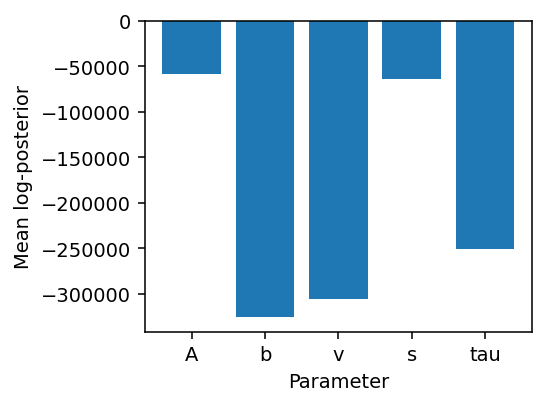

In [14]:
lps = [d[0].sample_stats['lp'].to_numpy().mean(axis=0).mean() for d in idata_class]
descs = ["A", "b", "v", "s", "tau"]
plt.figure(figsize=(4, 3))
plt.bar(descs, lps)
plt.xlabel("Parameter")
plt.ylabel("Mean log-posterior")
# plt.title("")
plt.tight_layout()
plt.show()

In [ ]:
summ_class[0][0]

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
v[0],6.010,0.554,5.257,6.794,0.276,0.212,4.0,4.0,5.877474e+15
v[1],4.477,1.015,2.822,5.548,0.507,0.388,4.0,4.0,5.877474e+15
v[2],4.505,1.544,2.752,6.395,0.770,0.590,4.0,4.0,5.341631e+15
v[3],4.963,1.864,2.708,7.051,0.930,0.713,4.0,4.0,5.341631e+15
v[4],5.664,1.513,3.527,7.140,0.755,0.578,4.0,4.0,5.341631e+15


In [21]:
conditions = ["focused", "divided", "high", "low", "expected", "unexpected"]
params = {"A": 0.5, "b": 1.0, "v": None, "s": 1.0, "tau": 0.1}

summs = {}
idatas = {}

subj = 9
for condition in range(6):
    rt = rts[condition, 9]
    choices = resps[condition, 9].astype('int32')
    idata = fit_one(
        5, rt, choices,
        draws=500, tune=200, chains=4,
        **params
    )
    summs[conditions[condition]] = az.summary(idata)
    idatas[conditions[condition]] = idata

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [v]


Output()

Sampling 4 chains for 200 tune and 500 draw iterations (800 + 2_000 draws total) took 13 seconds.
There were 1 divergences after tuning. Increase `target_accept` or reparameterize.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [v]


Output()

Sampling 4 chains for 200 tune and 500 draw iterations (800 + 2_000 draws total) took 12 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [v]


...

Sampling 4 chains for 200 tune and 500 draw iterations (800 + 2_000 draws total) took 12 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [v]


Output()

Sampling 4 chains for 200 tune and 500 draw iterations (800 + 2_000 draws total) took 12 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [v]


Output()

Sampling 4 chains for 200 tune and 500 draw iterations (800 + 2_000 draws total) took 5 seconds.
There were 2000 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [22]:
summs["focused"]

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
v[0],0.009,0.008,0.0,0.024,0.000,0.0,1006.0,691.0,1.00
v[1],0.013,0.013,0.0,0.038,0.000,0.0,965.0,870.0,1.00
v[2],0.022,0.019,0.0,0.057,0.000,0.0,992.0,624.0,1.01
v[3],0.032,0.027,0.0,0.080,0.001,0.0,1432.0,1088.0,1.00
v[4],0.008,0.007,0.0,0.022,0.000,0.0,1228.0,797.0,1.00


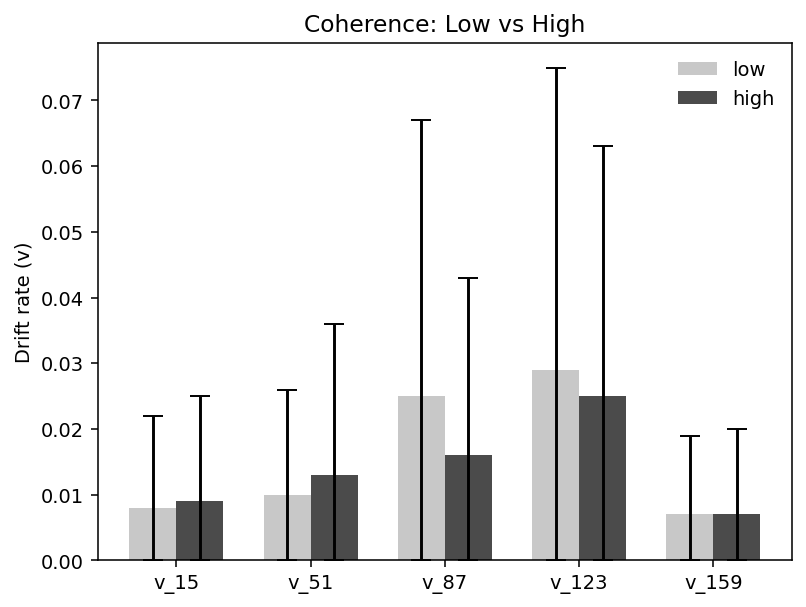

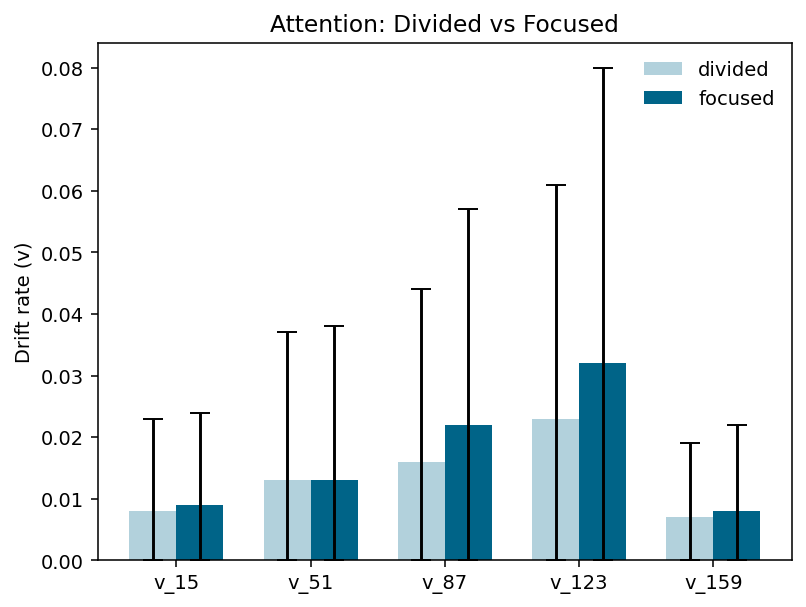

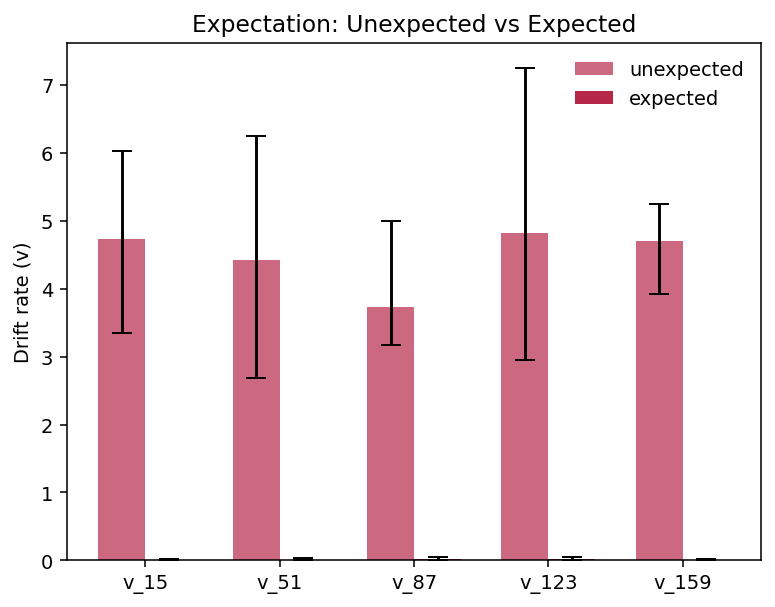

In [23]:
comparisons = [
    ("low", "high", "Coherence"),
    ("divided", "focused", "Attention"),
    ("unexpected", "expected", "Expectation")
]

colors = [("#c8c8c8", "#4b4b4b"), ("#b2d1dc", "#006488"), ("#cc6980", "#b62748")]

for (cond1, cond2, title), (color1, color2) in zip(comparisons, colors):
    df1 = summs[cond1]
    df2 = summs[cond2]

    # Extract means and HDIs
    means1 = df1['mean'].to_numpy()
    means2 = df2['mean'].to_numpy()
    lower1 = means1 - df1['hdi_3%'].to_numpy()
    upper1 = df1['hdi_97%'].to_numpy() - means1
    lower2 = means2 - df2['hdi_3%'].to_numpy()
    upper2 = df2['hdi_97%'].to_numpy() - means2

    # X positions
    x = range(len(means1))
    width = 0.35

    fig, ax = plt.subplots()
    ax.bar([xi - width/2 for xi in x], means1, width, label=cond1, 
           yerr=[lower1, upper1], capsize=5, color=color1)
    ax.bar([xi + width/2 for xi in x], means2, width, label=cond2, 
           yerr=[lower2, upper2], capsize=5, color=color2)

    ax.set_xticks(x)
    ax.set_xticklabels([f"v_{col_to_angle[i]}" for i in x])
    ax.set_title(f"{title}: {cond1.capitalize()} vs {cond2.capitalize()}")
    ax.set_ylabel("Drift rate (v)")
    ax.legend( loc='upper right', frameon=False)
    plt.show()


In [24]:
conditions = ["focused", "divided", "high", "low", "expected", "unexpected"]
params = {"A": 0.5, "b": None, "v": 1.0, "s": 1.0, "tau": 0.1},

summs = {}
idatas = {}

subj = 9
for condition in range(6):
    rt = rts[condition, 9]
    choices = resps[condition, 9].astype('int32')
    idata = fit_one(
        5, rt, choices,
        draws=500, tune=200, chains=4,
        **param,
    )
    summs[conditions[condition]] = az.summary(idata)
    idatas[conditions[condition]] = idata

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [tau]


Output()

Sampling 4 chains for 200 tune and 500 draw iterations (800 + 2_000 draws total) took 22 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [tau]


Output()

Sampling 4 chains for 200 tune and 500 draw iterations (800 + 2_000 draws total) took 605 seconds.
There were 13 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [tau]


...

Sampling 4 chains for 200 tune and 500 draw iterations (800 + 2_000 draws total) took 22 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [tau]


Output()

Sampling 4 chains for 200 tune and 500 draw iterations (800 + 2_000 draws total) took 513 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [tau]


Output()

Sampling 4 chains for 200 tune and 500 draw iterations (800 + 2_000 draws total) took 21 seconds.
There were 387 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


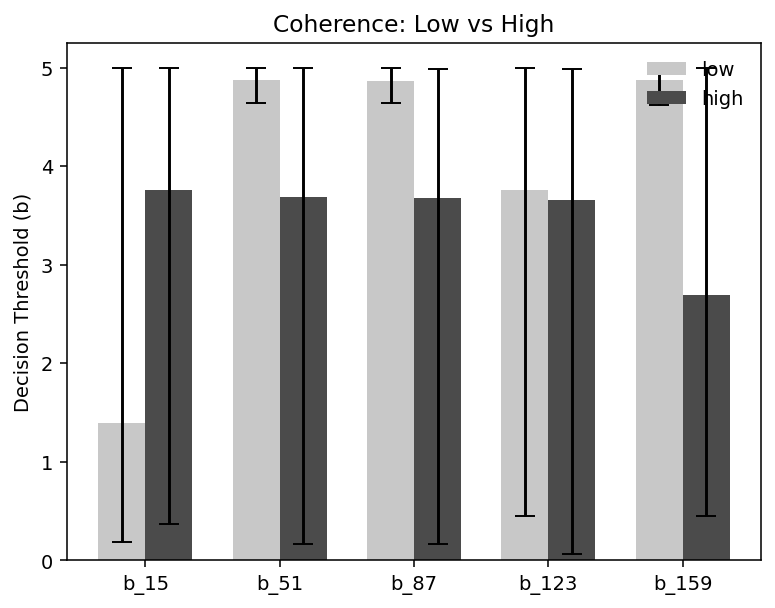

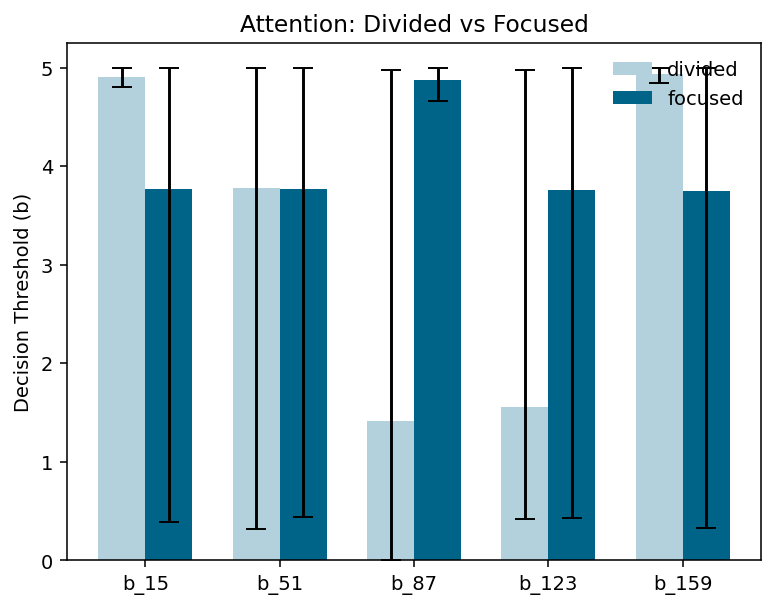

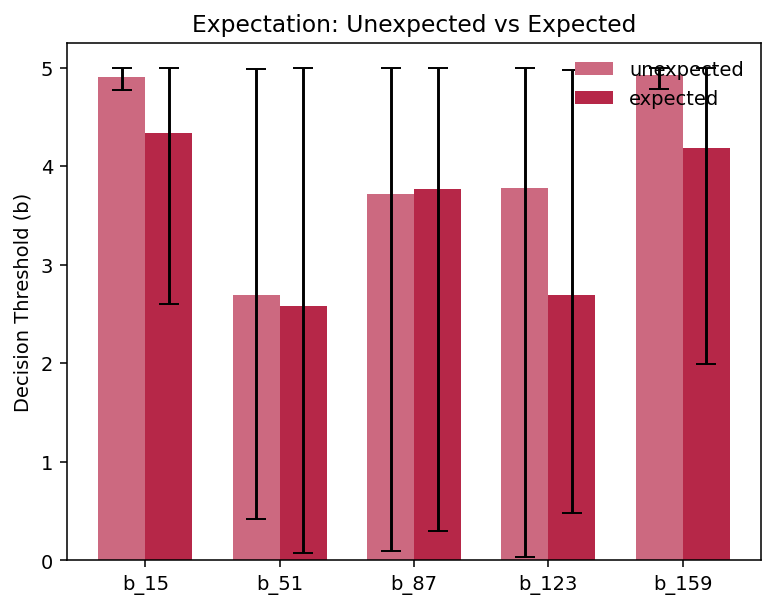

In [25]:
comparisons = [
    ("low", "high", "Coherence"),
    ("divided", "focused", "Attention"),
    ("unexpected", "expected", "Expectation")
]

colors = [("#c8c8c8", "#4b4b4b"), ("#b2d1dc", "#006488"), ("#cc6980", "#b62748")]

for (cond1, cond2, title), (color1, color2) in zip(comparisons, colors):
    df1 = summs[cond1]
    df2 = summs[cond2]

    # Extract means and HDIs
    means1 = df1['mean'].to_numpy()
    means2 = df2['mean'].to_numpy()
    lower1 = means1 - df1['hdi_3%'].to_numpy()
    upper1 = df1['hdi_97%'].to_numpy() - means1
    lower2 = means2 - df2['hdi_3%'].to_numpy()
    upper2 = df2['hdi_97%'].to_numpy() - means2

    # X positions
    x = range(len(means1))
    width = 0.35

    fig, ax = plt.subplots()
    ax.bar([xi - width/2 for xi in x], means1, width, label=cond1, 
           yerr=[lower1, upper1], capsize=5, color=color1)
    ax.bar([xi + width/2 for xi in x], means2, width, label=cond2, 
           yerr=[lower2, upper2], capsize=5, color=color2)

    ax.set_xticks(x)
    ax.set_xticklabels([f"b_{col_to_angle[i]}" for i in x])
    ax.set_title(f"{title}: {cond1.capitalize()} vs {cond2.capitalize()}")
    ax.set_ylabel("Decision Threshold (b)")
    ax.legend( loc='upper right', frameon=False)
    plt.show()


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from matplotlib.lines import Line2D

def plot_lba_multi(A, b, v, vcolors, tau):

    # Generate random start points within [0, A]
    y0s = np.random.uniform(0, A, size=len(v))
    # Compute dx for each trajectory and overall max for limits
    dx_vals = [(b - y0) / vi for y0, vi in zip(y0s, v)]
    max_dx = max(dx_vals)
    
    fig, ax = plt.subplots(figsize=(6, 4))

    # 1) Annotate τ on x-axis
    ax.annotate('', xy=(0, 0), xytext=(tau, 0),
                arrowprops=dict(arrowstyle='<->', linewidth=1.5))
    ax.text(tau / 2, -0.05 * b, 'τ', ha='center', va='top')

    # 2) Draw each evidence trajectory starting at (tau, y0s[i])
    for yi, vi, color in zip(y0s, v, vcolors):
        dx = (b - yi) / vi
        x0, x1 = tau, tau + dx
        ax.annotate('', xy=(x1, b), xytext=(x0, yi),
                    arrowprops=dict(arrowstyle='->', color=color, linewidth=2),
                    zorder=1)

    # 3) Draw the start-point range bar on top to hide trajectory bases
    bar_w = 0.02 * (tau + max_dx)
    rect = patches.Rectangle((tau, 0), bar_w, A,
                             facecolor='grey', alpha=0.7, zorder=2)
    ax.add_patch(rect)

    # 4) Annotate A at left of the bar
    ax.annotate('', xy=(tau, 0), xytext=(tau, A),
                arrowprops=dict(arrowstyle='<->', linewidth=1.5))
    ax.text(tau - 0.02 * (tau + max_dx), A / 2, 'A', ha='right', va='center')

    # 5) Threshold line and label
    ax.hlines(b, 0, tau + max_dx * 1.1, linestyles='--', color='k')
    ax.text(-0.05 * (tau + max_dx), b, 'b', ha='right', va='center')

    # 6) Axes labels & styling
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Accumulated evidence')
    ax.set_xlim(-0.1 * (tau + max_dx), tau + max_dx * 1.1)
    ax.set_ylim(0, b + 0.2 * A)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Build legend entries manually
    legend_lines = [
        Line2D([0], [0], color=vcolors[i], lw=2)
        for i in range(len(v))
    ]
    legend_labels = [f"v₍{col_to_angle[i]}°₎ = {v[i]:.2f}" for i in range(len(v))]

    ax.legend(legend_lines, legend_labels, title="Drift rates", loc="lower right", frameon=False)
    ax.set_title(f"Condition: {cond.capitalize()}")

    plt.show()


In [ ]:


# Mapping from column index to angle
col_to_angle = {0: 15, 1: 51, 2: 87, 3: 123, 4: 159}

# Colors for each drift index
vcolors = ['C0', 'C1', 'C2', 'C3', 'C4']

# Fixed LBA params (example values, adjust as needed)
A_fixed = 4.0
b_fixed = 4.0
sv_fixed = 1.0
tau_fixed = 0.2

# Loop through each condition in summs
for cond, df_sum in summs.items():
    # Extract the posterior mean of each drift rate v[0]...v[4]
    v_means = df_sum['mean'].values  # array of length 5

    # Plot the LBA schematic with multiple drifts
    plot_lba_multi(A=A_fixed, b=b_fixed, v=v_means, vcolors=vcolors, tau=tau_fixed)
